# Proyek Analisis Data: [Bike Sharing]
- **Nama:** [Kelvin Arianda]
- **Email:** [kelvinarianda01@gmail.com]
- **ID Dicoding:** [CDCC282D6Y1597
]

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Bagaimana pengaruh kondisi cuaca terhadap jumlah penyewaan sepeda?
- **Pertanyaan 2:** Kapan waktu dengan jumlah penyewaan sepeda tertinggi dalam sehari?



## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

#### Load df ...

In [2]:
df_day = pd.read_csv("day.csv")
df_hour = pd.read_csv("hour.csv")

df_day.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:** (Opsional)
- Dataset terdiri dari data harian (day.csv) dan per jam (hour.csv).
- Data mencakup informasi cuaca, waktu, dan jumlah penyewaan sepeda.


### Assessing Data

#### Identifying ... problem

In [3]:
df_day.info()
df_day.isnull().sum()
df_day.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


np.int64(0)

**Steps to Take:**
- Mengecek missing value
- Mengecek data duplikat
- Mengecek tipe data


**Insight:** (Opsional)
- Tidak ditemukan missing value pada dataset
- Tidak terdapat data duplikat
- Kolom dteday masih bertipe string dan perlu diubah menjadi datetime

### Cleaning Data

#### Fixing ... problem

In [4]:
df_day['dteday'] = pd.to_datetime(df_day['dteday'])
df_day.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    int64         
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    int64         
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    int64         
 8   weathersit  731 non-null    int64         
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: datetime64[ns](1), floa

**Insight:** (Opsional)
- Tipe data dteday berhasil diubah menjadi datetime sehingga dapat digunakan untuk analisis berbasis waktu

## Exploratory Data Analysis (EDA)

### Explore ...

In [5]:
# cuaca
df_day.groupby("weathersit")["cnt"].mean()

# jam
df_hour.groupby("hr")["cnt"].mean()

# working day
df_day.groupby("workingday")["cnt"].mean()

,cnt
workingday,
0,4330.168831
1,4584.820000


**Insight:** (Opsional)
- Penyewaan sepeda tertinggi terjadi saat cuaca cerah
- Penyewaan menurun saat cuaca buruk
- Terdapat dua puncak penyewaan, yaitu pagi dan sore hari
- Hari kerja memiliki jumlah penyewaan lebih tinggi dibandingkan hari libur

## Visualization & Explanatory Analysis

### Pertanyaan 1:

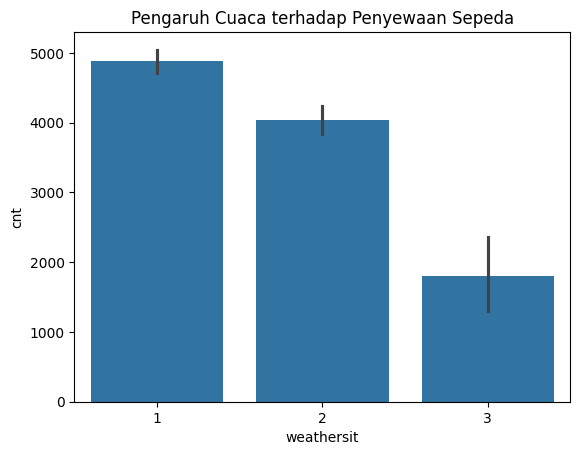

In [6]:
sns.barplot(x="weathersit", y="cnt", data=df_day)
plt.title("Pengaruh Cuaca terhadap Penyewaan Sepeda")
plt.show()

### Pertanyaan 2:

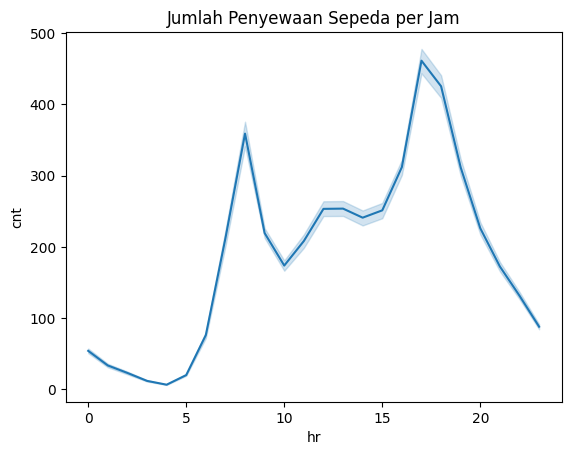

In [7]:
sns.lineplot(x="hr", y="cnt", data=df_hour)
plt.title("Jumlah Penyewaan Sepeda per Jam")
plt.show()

**Insight:** (Opsional)
- Penyewaan sepeda tertinggi terjadi pada kondisi cuaca cerah, menunjukkan bahwa faktor cuaca sangat memengaruhi perilaku pengguna.
- Jumlah penyewaan menurun signifikan pada kondisi cuaca buruk, menandakan rendahnya minat penggunaan saat kondisi tidak mendukung.
- Pola penyewaan menunjukkan dua puncak utama pada pagi (sekitar pukul 08.00) dan sore hari (sekitar pukul 17.00), yang berkaitan dengan aktivitas komuter.
- Hari kerja memiliki jumlah penyewaan lebih tinggi dibandingkan hari libur.

## Analisis Lanjutan (Opsional)

In [10]:
# kategorikan jumlah penyewaan
def kategori(cnt):
    if cnt < 2000:
        return "Low"
    elif cnt < 4000:
        return "Medium"
    else:
        return "High"

df_day["kategori"] = df_day["cnt"].apply(kategori)

df_day["kategori"].value_counts()

df_day.to_csv("main_data.csv", index=False)

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Kondisi cuaca memiliki pengaruh signifikan terhadap jumlah penyewaan sepeda. Penyewaan tertinggi terjadi saat cuaca cerah, sedangkan pada kondisi cuaca buruk jumlah penyewaan mengalami penurunan.
- **Conclusion pertanyaan 2:** Waktu penyewaan sepeda menunjukkan pola dengan dua puncak utama, yaitu pada pagi hari sekitar pukul 08.00 dan sore hari sekitar pukul 17.00, yang berkaitan dengan aktivitas berangkat dan pulang kerja.

**Rekomendasi Action Item:**
- Menambah jumlah sepeda pada jam sibuk (pagi dan sore hari) untuk memenuhi permintaan pengguna.
- Memberikan promo atau diskon pada kondisi cuaca buruk untuk meningkatkan minat penggunaan.
- Menyediakan lebih banyak sepeda pada hari kerja karena permintaan lebih tinggi dibandingkan hari libur.